# M04 - Final Pipeline: PCA + Minority Augmentation + Final Evaluation

Notebook này được viết lại từ đầu để chạy trong thư mục:

`AIL303m_FUDN_SUM26/workspace_Kiet/`

Nguồn dữ liệu chính nằm ở:

`AIL303m_FUDN_SUM26/paper/`

Flow chính:
1. Kiểm tra path project.
2. Load train/val/test.
3. Lấy danh sách class thiểu số từ M01 hoặc tự tính từ train.
4. Extract feature HOG Gray + Color Histogram.
5. Chạy TN3.1, TN3.2, TN3.3 trên validation.
6. Chọn best model bằng Val Macro F1.
7. Mở test split nếu `RUN_FINAL_TEST = True`.
8. Xuất final metrics, classification report, confusion matrix, top confusions và final model.

## 0. Config

Nếu chỉ chạy thử code, đặt:

```python
DEBUG_MODE = True
RUN_FINAL_TEST = False
```

Nếu muốn hoàn thành đúng mission M04 sau khi nhóm đã chốt validation, đặt:

```python
DEBUG_MODE = False
RUN_FINAL_TEST = True
```

In [1]:
from pathlib import Path
import time
import json
import warnings

warnings.filterwarnings("ignore")

# ===============================
# CONFIG CHÍNH
# ===============================
DEBUG_MODE = False            # True = chạy thử ít ảnh cho nhanh
MAX_IMAGES_PER_CLASS = 20     # chỉ dùng khi DEBUG_MODE=True

RUN_FINAL_TEST = True       # đổi True khi nhóm đã chốt model bằng validation
FORCE_RERUN_FINAL_TEST = False

IMAGE_SIZE = 64
PREPROCESS_MODE = "pad_square"     # "pad_square" hoặc "stretch"
FEATURE_MODE = "hog_gray_color_hist"
PCA_VARIANCE = 0.95

AUG_PER_IMAGE = 2                  # M04 yêu cầu 2-3 biến thể nhẹ
MINORITY_THRESHOLD = 30
RANDOM_STATE = 42

print("DEBUG_MODE:", DEBUG_MODE)
print("RUN_FINAL_TEST:", RUN_FINAL_TEST)

def df_to_records(df):
    return json.loads(df.to_json(orient="records", force_ascii=False))


def df_to_split(df):
    return json.loads(df.to_json(orient="split", force_ascii=False))


def write_report_json(path: Path, payload: dict):
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    print("Saved report:", path)



DEBUG_MODE: False
RUN_FINAL_TEST: True


## 1. Import thư viện

In [2]:
from pathlib import Path
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

np.random.seed(RANDOM_STATE)

print("Imports OK")
print("cv2:", cv2.__version__)

Imports OK
cv2: 4.13.0


## 2. Tự tìm project root và khai báo path

In [3]:
def find_project_root(start: Path) -> Path:
    """T?m th? m?c AIL303m_FUDN_SUM26 ho?c th? m?c c? paper/ v? workspace_Kiet/."""
    start = start.resolve()
    candidates = [start] + list(start.parents)

    for p in candidates:
        if p.name == "AIL303m_FUDN_SUM26" and (p / "paper").exists():
            return p

    for p in candidates:
        if (p / "paper").exists() and (p / "workspace_Kiet").exists():
            return p

    raise FileNotFoundError(
        "Kh?ng t?m th?y project root. H?y ch?y notebook trong AIL303m_FUDN_SUM26 ho?c workspace_Kiet."
    )

CURRENT = Path.cwd()
PROJECT = find_project_root(CURRENT)

PAPER = PROJECT / "paper"
DATASET = PAPER / "cropped_dataset"
TRAIN_DIR = DATASET / "train"
VAL_DIR = DATASET / "val"
TEST_DIR = DATASET / "test"

RESULT = PAPER / "result"
PHASE1 = RESULT / "exphase_1_result"
PHASE2 = RESULT / "exphase_2_result"
PHASE3 = RESULT / "exphase_3_result"

WORKSPACE = PROJECT / "workspace_Kiet"
SUPPORT_DIR = WORKSPACE / "support"
OUTPUT_DIR = WORKSPACE / "m04_outputs"
CACHE_DIR = OUTPUT_DIR / "cache"
DATASET_OUTPUT_DIR = OUTPUT_DIR / "dataset"
VALIDATION_OUTPUT_DIR = OUTPUT_DIR / "validation"
FINAL_OUTPUT_DIR = OUTPUT_DIR / "final_test"

for folder in [OUTPUT_DIR, CACHE_DIR, DATASET_OUTPUT_DIR, VALIDATION_OUTPUT_DIR, FINAL_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

paths = pd.DataFrame([
    ["CURRENT", CURRENT],
    ["PROJECT", PROJECT],
    ["PAPER", PAPER],
    ["DATASET", DATASET],
    ["TRAIN_DIR", TRAIN_DIR],
    ["VAL_DIR", VAL_DIR],
    ["TEST_DIR", TEST_DIR],
    ["PHASE1", PHASE1],
    ["PHASE2", PHASE2],
    ["PHASE3", PHASE3],
    ["WORKSPACE", WORKSPACE],
    ["SUPPORT_DIR", SUPPORT_DIR],
    ["OUTPUT_DIR", OUTPUT_DIR],
    ["CACHE_DIR", CACHE_DIR],
    ["DATASET_OUTPUT_DIR", DATASET_OUTPUT_DIR],
    ["VALIDATION_OUTPUT_DIR", VALIDATION_OUTPUT_DIR],
    ["FINAL_OUTPUT_DIR", FINAL_OUTPUT_DIR],
], columns=["Name", "Path"])

display(paths)

for p in [PAPER, DATASET, TRAIN_DIR, VAL_DIR, TEST_DIR, PHASE1, PHASE2, PHASE3, WORKSPACE]:
    assert p.exists(), f"Kh?ng t?m th?y path: {p}"

print("Path check OK")


,Name,Path
0,CURRENT,e:\tai lieu\machine learning\project_final\AIL...
1,PROJECT,E:\tai lieu\machine learning\project_final\AIL...
2,PAPER,E:\tai lieu\machine learning\project_final\AIL...
3,DATASET,E:\tai lieu\machine learning\project_final\AIL...
4,TRAIN_DIR,E:\tai lieu\machine learning\project_final\AIL...
5,VAL_DIR,E:\tai lieu\machine learning\project_final\AIL...
6,TEST_DIR,E:\tai lieu\machine learning\project_final\AIL...
7,PHASE1,E:\tai lieu\machine learning\project_final\AIL...
8,PHASE2,E:\tai lieu\machine learning\project_final\AIL...
9,PHASE3,E:\tai lieu\machine learning\project_final\AIL...


Path check OK


## 3. Đọc artifact có sẵn từ Phase 1, Phase 2, Phase 3

In [4]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print("Không tìm thấy:", path)
    return pd.DataFrame()

phase1_validation = read_csv_if_exists(PHASE1 / "feature_svm_validation_results.csv")
phase1_test_metrics = read_csv_if_exists(PHASE1 / "feature_svm_best_test_metrics.csv")
phase1_test_confusions = read_csv_if_exists(PHASE1 / "feature_svm_best_test_confusions.csv")

phase2_results = read_csv_if_exists(PHASE2 / "feature_svm_phase2_results.csv")
phase2_validation = read_csv_if_exists(PHASE2 / "feature_svm_validation_results.csv")
phase2_val_report_edge = read_csv_if_exists(PHASE2 / "val_classification_report_edge_histogram.csv")
phase2_val_top_confusions_edge = read_csv_if_exists(PHASE2 / "val_top_confusions_edge_histogram.csv")

phase3_search_plan = read_csv_if_exists(PHASE3 / "phase3_search_plan.csv")
phase3_partial = read_csv_if_exists(PHASE3 / "phase3_validation_results_partial.csv")

status = pd.DataFrame([
    ["Phase 1 validation", phase1_validation.shape],
    ["Phase 1 test metrics", phase1_test_metrics.shape],
    ["Phase 2 results", phase2_results.shape],
    ["Phase 2 val report edge", phase2_val_report_edge.shape],
    ["Phase 3 search plan", phase3_search_plan.shape],
    ["Phase 3 partial", phase3_partial.shape],
], columns=["Artifact", "Shape"])

display(status)

,Artifact,Shape
0,Phase 1 validation,"(10, 11)"
1,Phase 1 test metrics,"(1, 8)"
2,Phase 2 results,"(4, 13)"
3,Phase 2 val report edge,"(50, 5)"
4,Phase 3 search plan,"(120, 21)"
5,Phase 3 partial,"(5, 36)"


## 4. Load danh sách ảnh train/val/test

In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_image_files(split_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        label = class_dir.name
        for img_path in sorted(class_dir.rglob("*")):
            if img_path.suffix.lower() in IMG_EXTS:
                rows.append({"path": str(img_path), "label": label})
    return pd.DataFrame(rows)

train_df = list_image_files(TRAIN_DIR)
val_df = list_image_files(VAL_DIR)
test_df = list_image_files(TEST_DIR)

if DEBUG_MODE:
    def limit_per_class(df, n=MAX_IMAGES_PER_CLASS):
        return df.groupby("label", group_keys=False).head(n).reset_index(drop=True)
    train_df = limit_per_class(train_df)
    val_df = limit_per_class(val_df)
    test_df = limit_per_class(test_df)
    print("DEBUG_MODE=True: đã giới hạn số ảnh mỗi class.")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

display(train_df.head())

train: (6605, 2)
val: (824, 2)
test: (851, 2)


,path,label
0,E:\tai lieu\machine learning\project_final\AIL...,B.8a
1,E:\tai lieu\machine learning\project_final\AIL...,B.8a
2,E:\tai lieu\machine learning\project_final\AIL...,B.8a
3,E:\tai lieu\machine learning\project_final\AIL...,B.8a
4,E:\tai lieu\machine learning\project_final\AIL...,B.8a


## 5. Tính class count và xác định minority classes

In [6]:
def count_by_class(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    return (
        df["label"]
        .value_counts()
        .sort_index()
        .rename_axis("Class")
        .reset_index(name=col_name)
    )

train_counts = count_by_class(train_df, "Train")
val_counts = count_by_class(val_df, "Val")
test_counts = count_by_class(test_df, "Test")

class_counts = train_counts.merge(val_counts, on="Class", how="outer").merge(test_counts, on="Class", how="outer")
class_counts = class_counts.fillna(0)
class_counts[["Train", "Val", "Test"]] = class_counts[["Train", "Val", "Test"]].astype(int)

minority_from_support = SUPPORT_DIR / "minority_classes.csv"

if minority_from_support.exists():
    minority_df = pd.read_csv(minority_from_support)
    if "Class" in minority_df.columns:
        minority_classes = sorted(minority_df["Class"].astype(str).unique().tolist())
    elif "label" in minority_df.columns:
        minority_classes = sorted(minority_df["label"].astype(str).unique().tolist())
    else:
        minority_classes = sorted(class_counts.loc[class_counts["Train"] < MINORITY_THRESHOLD, "Class"].tolist())
else:
    minority_classes = sorted(class_counts.loc[class_counts["Train"] < MINORITY_THRESHOLD, "Class"].tolist())

minority_table = class_counts[class_counts["Class"].isin(minority_classes)].sort_values("Train")

display(class_counts.head(20))
display(minority_table)

class_counts_path = DATASET_OUTPUT_DIR / "m04_class_counts.csv"
minority_path = DATASET_OUTPUT_DIR / "m04_minority_classes.csv"
class_counts.to_csv(class_counts_path, index=False, encoding="utf-8-sig")
minority_table.to_csv(minority_path, index=False, encoding="utf-8-sig")

print("Saved:", class_counts_path)
print("Saved:", minority_path)
print("S? class thi?u s?:", len(minority_classes))
print(minority_classes)


,Class,Train,Val,Test
0,B.8a,65,8,9
1,Camera,30,4,4
2,I.407a,156,19,20
3,I.409,20,3,3
4,I.434a,170,21,22
5,P.102,376,47,47
6,P.103a,41,5,6
7,P.104,36,4,5
8,P.106a_Xe tải,68,8,9
9,P.107,171,21,22


,Class,Train,Val,Test
26,R.301e,16,2,3
38,W.205c,17,2,3
30,S.505a_Xe máy,20,2,3
3,I.409,20,3,3
32,S.505a_Xe tải và công,21,3,3
44,W.239b_,21,3,3
35,W.203c,23,3,3
16,P.124d,23,3,3
36,W.205a,26,3,4
43,W.225,28,4,4


Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\dataset\m04_class_counts.csv
Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\dataset\m04_minority_classes.csv
S? class thi?u s?: 10
['I.409', 'P.124d', 'R.301e', 'S.505a_Xe máy', 'S.505a_Xe tải và công', 'W.203c', 'W.205a', 'W.205c', 'W.225', 'W.239b_']


## 6. Hàm tiền xử lý ảnh, augmentation và trích xuất feature

In [7]:
def pad_square_image(img: np.ndarray, fill_value=0) -> np.ndarray:
    h, w = img.shape[:2]
    size = max(h, w)

    if img.ndim == 2:
        canvas = np.full((size, size), fill_value, dtype=img.dtype)
        y0 = (size - h) // 2
        x0 = (size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
    else:
        canvas = np.full((size, size, img.shape[2]), fill_value, dtype=img.dtype)
        y0 = (size - h) // 2
        x0 = (size - w) // 2
        canvas[y0:y0+h, x0:x0+w, :] = img

    return canvas

def preprocess_image(img_bgr: np.ndarray, image_size=IMAGE_SIZE, mode=PREPROCESS_MODE) -> np.ndarray:
    if img_bgr is None:
        raise ValueError("img_bgr is None")

    if mode == "pad_square":
        img_bgr = pad_square_image(img_bgr, fill_value=0)
    elif mode == "stretch":
        pass
    else:
        raise ValueError(f"PREPROCESS_MODE không hợp lệ: {mode}")

    img_bgr = cv2.resize(img_bgr, (image_size, image_size), interpolation=cv2.INTER_AREA)
    return img_bgr

def read_image(path: str) -> np.ndarray:
    """
    ??c ?nh an to?n tr?n Windows, h? tr? path c? ti?ng Vi?t/k? t? Unicode.
    Kh?ng d?ng cv2.imread tr?c ti?p v? d? l?i v?i folder nh? 'P.106a_Xe t?i'.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File kh?ng t?n t?i: {path}")

    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)

    if img is None:
        raise FileNotFoundError(f"Kh?ng decode ???c ?nh: {path}")

    return img


def augment_light(img_bgr: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    # Minority augmentation nhẹ trên ảnh 2D: rotate +/- 10 độ + brightness +/- 15%.
    img = img_bgr.copy()
    h, w = img.shape[:2]

    angle = rng.uniform(-10, 10)
    scale = rng.uniform(0.95, 1.05)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    img = cv2.warpAffine(
        img, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    alpha = rng.uniform(0.85, 1.15)
    beta = rng.uniform(-8, 8)
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    return img

def create_hog_descriptor(image_size=IMAGE_SIZE):
    win_size = (image_size, image_size)
    block_size = (16, 16)
    block_stride = (8, 8)
    cell_size = (8, 8)
    nbins = 9
    return cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, nbins)

HOG = create_hog_descriptor(IMAGE_SIZE)

def extract_feature_from_image(img_bgr: np.ndarray) -> np.ndarray:
    img_bgr = preprocess_image(img_bgr, image_size=IMAGE_SIZE, mode=PREPROCESS_MODE)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hog_feat = HOG.compute(gray).reshape(-1).astype(np.float32)

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist_features = []
    # 16 bins mỗi kênh H/S/V => 48 chiều
    for channel in range(3):
        hist = cv2.calcHist([hsv], [channel], None, [16], [0, 256]).reshape(-1)
        hist = hist.astype(np.float32)
        hist = hist / (hist.sum() + 1e-8)
        hist_features.append(hist)

    color_hist = np.concatenate(hist_features).astype(np.float32)
    feat = np.concatenate([hog_feat, color_hist]).astype(np.float32)
    return feat

def extract_features_from_df(df: pd.DataFrame, desc="extract") -> tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    total = len(df)

    for i, row in enumerate(df.itertuples(index=False), start=1):
        img = read_image(row.path)
        feat = extract_feature_from_image(img)
        X.append(feat)
        y.append(str(row.label))

        if i % 500 == 0 or i == total:
            print(f"{desc}: {i}/{total}")

    return np.vstack(X).astype(np.float32), np.array(y).astype(str)

def build_augmented_train(df: pd.DataFrame, minority_classes: list[str], aug_per_image=AUG_PER_IMAGE):
    rng = np.random.default_rng(RANDOM_STATE)
    X, y = [], []

    total = len(df)
    aug_count = 0

    for i, row in enumerate(df.itertuples(index=False), start=1):
        img = read_image(row.path)
        label = str(row.label)

        X.append(extract_feature_from_image(img))
        y.append(label)

        if label in minority_classes:
            for _ in range(aug_per_image):
                aug_img = augment_light(img, rng)
                X.append(extract_feature_from_image(aug_img))
                y.append(label)
                aug_count += 1

        if i % 500 == 0 or i == total:
            print(f"train + aug: {i}/{total}, aug={aug_count}")

    return np.vstack(X).astype(np.float32), np.array(y).astype(str), aug_count

print("Feature functions OK")
print("Expected feature dimension:", len(extract_feature_from_image(read_image(train_df.iloc[0]['path']))))

Feature functions OK
Expected feature dimension: 1812


## 7. Extract feature train/val

In [8]:
feature_cache = CACHE_DIR / f"m04_features_{FEATURE_MODE}_{PREPROCESS_MODE}_{IMAGE_SIZE}_debug{DEBUG_MODE}.npz"

if feature_cache.exists():
    print("Load feature cache:", feature_cache)
    cache = np.load(feature_cache, allow_pickle=True)
    X_train = cache["X_train"]
    y_train = cache["y_train"].astype(str)
    X_val = cache["X_val"]
    y_val = cache["y_val"].astype(str)
else:
    X_train, y_train = extract_features_from_df(train_df, desc="train feature")
    X_val, y_val = extract_features_from_df(val_df, desc="val feature")
    np.savez_compressed(
        feature_cache,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
    )
    print("Saved feature cache:", feature_cache)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)


Load feature cache: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\cache\m04_features_hog_gray_color_hist_pad_square_64_debugFalse.npz
X_train: (6605, 1812)
X_val: (824, 1812)
y_train: (6605,)
y_val: (824,)


## 8. Tạo tập train augmentation cho TN3.3

In [9]:
aug_cache = CACHE_DIR / f"m04_augmented_features_{FEATURE_MODE}_{PREPROCESS_MODE}_{IMAGE_SIZE}_aug{AUG_PER_IMAGE}_debug{DEBUG_MODE}.npz"

if aug_cache.exists():
    print("Load augmented cache:", aug_cache)
    cache = np.load(aug_cache, allow_pickle=True)
    X_train_aug = cache["X_train_aug"]
    y_train_aug = cache["y_train_aug"].astype(str)
    aug_count = int(cache["aug_count"])
else:
    X_train_aug, y_train_aug, aug_count = build_augmented_train(train_df, minority_classes, aug_per_image=AUG_PER_IMAGE)
    np.savez_compressed(
        aug_cache,
        X_train_aug=X_train_aug,
        y_train_aug=y_train_aug,
        aug_count=np.array(aug_count),
    )
    print("Saved augmented cache:", aug_cache)

print("X_train_aug:", X_train_aug.shape)
print("y_train_aug:", y_train_aug.shape)
print("Augmented samples:", aug_count)


Load augmented cache: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\cache\m04_augmented_features_hog_gray_color_hist_pad_square_64_aug2_debugFalse.npz
X_train_aug: (7035, 1812)
y_train_aug: (7035,)
Augmented samples: 430


## 9. Hàm train/evaluate experiment

In [10]:
def make_model(use_pca: bool):
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)))
    steps.append((
        "model",
        SVC(
            kernel="rbf",
            C=10.0,
            gamma="scale",
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    ))
    return Pipeline(steps)

def evaluate_experiment(exp_id: str, exp_name: str, Xtr, ytr, Xv, yv, use_pca: bool):
    print(f"\n===== {exp_id}: {exp_name} =====")
    pipe = make_model(use_pca=use_pca)

    start = time.perf_counter()
    pipe.fit(Xtr, ytr)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    pred = pipe.predict(Xv)
    infer_ms = (time.perf_counter() - start) / len(yv) * 1000

    metrics = {
        "experiment_id": exp_id,
        "experiment_name": exp_name,
        "use_pca": use_pca,
        "train_samples": int(len(ytr)),
        "feature_dim_before_pca": int(Xtr.shape[1]),
        "feature_dim_after_pca": int(pipe.named_steps["pca"].n_components_) if use_pca else int(Xtr.shape[1]),
        "val_accuracy": accuracy_score(yv, pred),
        "val_macro_precision": precision_score(yv, pred, average="macro", zero_division=0),
        "val_macro_recall": recall_score(yv, pred, average="macro", zero_division=0),
        "val_macro_f1": f1_score(yv, pred, average="macro", zero_division=0),
        "val_weighted_f1": f1_score(yv, pred, average="weighted", zero_division=0),
        "train_time_sec": train_time,
        "inference_ms_per_image": infer_ms,
    }

    print(metrics)

    return {
        "id": exp_id,
        "name": exp_name,
        "model": pipe,
        "pred": pred,
        "metrics": metrics
    }

def top_confusions_from_cm(cm: np.ndarray, labels: list[str], top_n=30) -> pd.DataFrame:
    rows = []
    for i, true_label in enumerate(labels):
        for j, pred_label in enumerate(labels):
            if i != j and cm[i, j] > 0:
                rows.append({
                    "true_class": true_label,
                    "predicted_class": pred_label,
                    "count": int(cm[i, j])
                })
    if not rows:
        return pd.DataFrame(columns=["true_class", "predicted_class", "count"])
    return pd.DataFrame(rows).sort_values("count", ascending=False).head(top_n).reset_index(drop=True)

print("Training functions OK")

Training functions OK


## 10. Chạy TN3.1, TN3.2, TN3.3 trên validation

In [11]:
experiments = []

experiments.append(
    evaluate_experiment(
        "TN3.1",
        "No PCA, No Augmentation",
        X_train, y_train, X_val, y_val,
        use_pca=False
    )
)

experiments.append(
    evaluate_experiment(
        "TN3.2",
        "PCA 95%, No Augmentation",
        X_train, y_train, X_val, y_val,
        use_pca=True
    )
)

experiments.append(
    evaluate_experiment(
        "TN3.3",
        "PCA 95% + Minority Augmentation",
        X_train_aug, y_train_aug, X_val, y_val,
        use_pca=True
    )
)

validation_results = pd.DataFrame([e["metrics"] for e in experiments])
validation_results = validation_results.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

display(validation_results)

validation_results_path = VALIDATION_OUTPUT_DIR / "m04_validation_results_tn31_tn32_tn33.csv"
validation_results.to_csv(validation_results_path, index=False, encoding="utf-8-sig")
print("Saved:", validation_results_path)



===== TN3.1: No PCA, No Augmentation =====
{'experiment_id': 'TN3.1', 'experiment_name': 'No PCA, No Augmentation', 'use_pca': False, 'train_samples': 6605, 'feature_dim_before_pca': 1812, 'feature_dim_after_pca': 1812, 'val_accuracy': 0.962378640776699, 'val_macro_precision': 0.9652720138232216, 'val_macro_recall': 0.9365244168104602, 'val_macro_f1': 0.9485221562770865, 'val_weighted_f1': 0.9611676719200869, 'train_time_sec': 14.128260200013756, 'inference_ms_per_image': 5.882065169890728}

===== TN3.2: PCA 95%, No Augmentation =====
{'experiment_id': 'TN3.2', 'experiment_name': 'PCA 95%, No Augmentation', 'use_pca': True, 'train_samples': 6605, 'feature_dim_before_pca': 1812, 'feature_dim_after_pca': 569, 'val_accuracy': 0.9660194174757282, 'val_macro_precision': 0.9634600168494488, 'val_macro_recall': 0.9408144872429912, 'val_macro_f1': 0.9503890238740881, 'val_weighted_f1': 0.9647620297099628, 'train_time_sec': 5.431003400008194, 'inference_ms_per_image': 1.8749367718555732}

====

,experiment_id,experiment_name,use_pca,train_samples,feature_dim_before_pca,feature_dim_after_pca,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,train_time_sec,inference_ms_per_image
0,TN3.3,PCA 95% + Minority Augmentation,True,7035,1812,571,0.967233,0.964426,0.952438,0.957736,0.966070,6.462106,2.555664
1,TN3.2,"PCA 95%, No Augmentation",True,6605,1812,569,0.966019,0.963460,0.940814,0.950389,0.964762,5.431003,1.874937
2,TN3.1,"No PCA, No Augmentation",False,6605,1812,1812,0.962379,0.965272,0.936524,0.948522,0.961168,14.128260,5.882065


Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_validation_results_tn31_tn32_tn33.csv


## 11. So sánh Recall/F1 của class thiểu số trên validation

In [12]:
minority_rows = []

for exp in experiments:
    report_dict = classification_report(y_val, exp["pred"], output_dict=True, zero_division=0)

    for cls in minority_classes:
        if cls in report_dict:
            minority_rows.append({
                "experiment_id": exp["id"],
                "experiment_name": exp["name"],
                "Class": cls,
                "val_precision": report_dict[cls]["precision"],
                "val_recall": report_dict[cls]["recall"],
                "val_f1": report_dict[cls]["f1-score"],
                "val_support": int(report_dict[cls]["support"]),
            })

minority_val_report = pd.DataFrame(minority_rows)
display(minority_val_report)

minority_val_report_path = VALIDATION_OUTPUT_DIR / "m04_minority_validation_report_by_experiment.csv"
minority_val_report.to_csv(minority_val_report_path, index=False, encoding="utf-8-sig")
print("Saved:", minority_val_report_path)


,experiment_id,experiment_name,Class,val_precision,val_recall,val_f1,val_support
0,TN3.1,"No PCA, No Augmentation",I.409,1.0,1.000000,1.000000,3
1,TN3.1,"No PCA, No Augmentation",P.124d,1.0,1.000000,1.000000,3
2,TN3.1,"No PCA, No Augmentation",R.301e,1.0,1.000000,1.000000,2
3,TN3.1,"No PCA, No Augmentation",S.505a_Xe máy,1.0,1.000000,1.000000,2
4,TN3.1,"No PCA, No Augmentation",S.505a_Xe tải và công,1.0,1.000000,1.000000,3
5,TN3.1,"No PCA, No Augmentation",W.203c,1.0,1.000000,1.000000,3
6,TN3.1,"No PCA, No Augmentation",W.205a,1.0,0.666667,0.800000,3
7,TN3.1,"No PCA, No Augmentation",W.205c,0.0,0.000000,0.000000,2
8,TN3.1,"No PCA, No Augmentation",W.225,1.0,0.750000,0.857143,4
9,TN3.1,"No PCA, No Augmentation",W.239b_,1.0,1.000000,1.000000,3


Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_minority_validation_report_by_experiment.csv


## 12. Chọn best model bằng Val Macro F1

In [13]:
best_row = validation_results.iloc[0].copy()
best_exp_id = best_row["experiment_id"]
best_exp = next(e for e in experiments if e["id"] == best_exp_id)

print("Best validation experiment:", best_exp_id)
display(pd.DataFrame([best_row]))

best_validation_model_path = VALIDATION_OUTPUT_DIR / "m04_best_validation_model.joblib"
joblib.dump(best_exp["model"], best_validation_model_path)

print("Saved best validation model:", best_validation_model_path)


Best validation experiment: TN3.3


,experiment_id,experiment_name,use_pca,train_samples,feature_dim_before_pca,feature_dim_after_pca,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,train_time_sec,inference_ms_per_image
0,TN3.3,PCA 95% + Minority Augmentation,True,7035,1812,571,0.967233,0.964426,0.952438,0.957736,0.96607,6.462106,2.555664


Saved best validation model: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_best_validation_model.joblib


## 13. Lưu confusion matrix validation của best model

In [14]:
val_labels = sorted(np.unique(y_val))
val_cm = confusion_matrix(y_val, best_exp["pred"], labels=val_labels)

val_cm_df = pd.DataFrame(val_cm, index=val_labels, columns=val_labels)
val_top_confusions = top_confusions_from_cm(val_cm, val_labels, top_n=30)

display(val_top_confusions)

val_cm_path = VALIDATION_OUTPUT_DIR / "m04_best_validation_confusion_matrix.csv"
val_top_path = VALIDATION_OUTPUT_DIR / "m04_best_validation_top_confusions.csv"
validation_summary_path = VALIDATION_OUTPUT_DIR / "m04_final_pipeline_summary.json"

val_cm_df.to_csv(val_cm_path, encoding="utf-8-sig")
val_top_confusions.to_csv(val_top_path, index=False, encoding="utf-8-sig")

validation_summary = {
    "mission": "M04 - validation pipeline",
    "status": "completed_validation",
    "project": str(PROJECT),
    "dataset": str(DATASET),
    "feature_mode": FEATURE_MODE,
    "image_size": IMAGE_SIZE,
    "preprocess_mode": PREPROCESS_MODE,
    "pca_variance": PCA_VARIANCE,
    "minority_threshold": MINORITY_THRESHOLD,
    "best_validation_experiment": str(best_exp_id),
    "best_validation_macro_f1": float(best_row["val_macro_f1"]),
    "best_validation_accuracy": float(best_row["val_accuracy"]),
    "outputs": {
        "validation_results": str(validation_results_path),
        "minority_validation_report": str(minority_val_report_path),
        "best_validation_model": str(best_validation_model_path),
        "best_validation_confusion_matrix": str(val_cm_path),
        "best_validation_top_confusions": str(val_top_path),
    },
}

validation_summary_path.write_text(json.dumps(validation_summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("Saved:", val_cm_path)
print("Saved:", val_top_path)
print("Saved:", validation_summary_path)


,true_class,predicted_class,count
0,P.131a,P.130,4
1,W.207,W.224,3
2,P.127_40,P.127_60,2
3,W.205c,W.245a,2
4,P.124a_,P.127_40,1
5,P.117_,P.130,1
6,P.111,P.130,1
7,B.8a,P.130,1
8,P.127_60,P.127_80,1
9,P.127_80,P.127_60,1


Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_best_validation_confusion_matrix.csv
Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_best_validation_top_confusions.csv
Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_final_pipeline_summary.json


## 14. Final test - chỉ chạy nếu RUN_FINAL_TEST = True

In [15]:
final_metrics_path = FINAL_OUTPUT_DIR / "m04_final_test_metrics.csv"

if not RUN_FINAL_TEST:
    print("RUN_FINAL_TEST = False")
    print("RUN_FINAL_TEST = False; test split is still locked.")
    print("To complete M04, set RUN_FINAL_TEST = True in the config cell and run again.")
else:
    if final_metrics_path.exists() and not FORCE_RERUN_FINAL_TEST:
        print("Final test output already exists; notebook will not rerun test.")
        print("Loading saved final outputs to preserve the one-time test rule.")

        test_metrics_df = pd.read_csv(final_metrics_path)
        display(test_metrics_df)

        test_report_path = FINAL_OUTPUT_DIR / "m04_final_test_classification_report.csv"
        test_cm_path = FINAL_OUTPUT_DIR / "m04_final_test_confusion_matrix.csv"
        test_top_path = FINAL_OUTPUT_DIR / "m04_final_test_top_confusions.csv"
        final_model_path = FINAL_OUTPUT_DIR / "m04_final_model.joblib"
        final_summary_path = FINAL_OUTPUT_DIR / "m04_final_test_summary.json"

        if test_report_path.exists():
            test_report_df = pd.read_csv(test_report_path)
            display(test_report_df)
        else:
            print("Missing file:", test_report_path)

        if test_top_path.exists():
            test_top_confusions = pd.read_csv(test_top_path)
            display(test_top_confusions)
        else:
            print("Missing file:", test_top_path)

        print("Final metrics:", final_metrics_path)
        print("Final classification report:", test_report_path)
        print("Final confusion matrix:", test_cm_path)
        print("Final top confusions:", test_top_path)
        print("Final model:", final_model_path)
        print("Final summary:", final_summary_path)
    else:
        print("RUN_FINAL_TEST = True")
        print("Loading test split and running final evaluation once.")

        X_test_cache = CACHE_DIR / f"m04_test_features_{FEATURE_MODE}_{PREPROCESS_MODE}_{IMAGE_SIZE}_debug{DEBUG_MODE}.npz"

        if X_test_cache.exists():
            print("Load test feature cache:", X_test_cache)
            cache = np.load(X_test_cache, allow_pickle=True)
            X_test = cache["X_test"]
            y_test = cache["y_test"].astype(str)
        else:
            X_test, y_test = extract_features_from_df(test_df, desc="test feature")
            np.savez_compressed(X_test_cache, X_test=X_test, y_test=y_test)
            print("Saved test feature cache:", X_test_cache)

        print("X_test:", X_test.shape)
        print("y_test:", y_test.shape)

        start = time.perf_counter()
        y_test_pred = best_exp["model"].predict(X_test)
        test_infer_ms = (time.perf_counter() - start) / len(y_test) * 1000

        test_metrics = {
            "best_experiment_id": best_exp_id,
            "best_experiment_name": best_row["experiment_name"],
            "feature_mode": FEATURE_MODE,
            "image_size": IMAGE_SIZE,
            "preprocess_mode": PREPROCESS_MODE,
            "pca_variance": PCA_VARIANCE,
            "test_samples": int(len(y_test)),
            "test_accuracy": accuracy_score(y_test, y_test_pred),
            "test_macro_precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
            "test_macro_recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
            "test_macro_f1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
            "test_weighted_f1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
            "test_inference_ms_per_image": test_infer_ms,
        }

        test_metrics_df = pd.DataFrame([test_metrics])
        display(test_metrics_df)
        test_metrics_df.to_csv(final_metrics_path, index=False, encoding="utf-8-sig")

        test_report_dict = classification_report(y_test, y_test_pred, output_dict=True, zero_division=0)
        test_report_df = pd.DataFrame(test_report_dict).T.reset_index().rename(columns={"index": "Class"})
        display(test_report_df)

        test_report_path = FINAL_OUTPUT_DIR / "m04_final_test_classification_report.csv"
        test_report_df.to_csv(test_report_path, index=False, encoding="utf-8-sig")

        test_labels = sorted(np.unique(y_test))
        test_cm = confusion_matrix(y_test, y_test_pred, labels=test_labels)
        test_cm_df = pd.DataFrame(test_cm, index=test_labels, columns=test_labels)
        test_top_confusions = top_confusions_from_cm(test_cm, test_labels, top_n=30)
        display(test_top_confusions)

        test_cm_path = FINAL_OUTPUT_DIR / "m04_final_test_confusion_matrix.csv"
        test_top_path = FINAL_OUTPUT_DIR / "m04_final_test_top_confusions.csv"
        test_cm_df.to_csv(test_cm_path, encoding="utf-8-sig")
        test_top_confusions.to_csv(test_top_path, index=False, encoding="utf-8-sig")

        final_model_path = FINAL_OUTPUT_DIR / "m04_final_model.joblib"
        joblib.dump(best_exp["model"], final_model_path)
        print("Saved final model:", final_model_path)

        final_summary = {
            "mission": "M04 - PCA, Minority Augmentation and Final Evaluation",
            "status": "completed_final_test",
            "project": str(PROJECT),
            "dataset": str(DATASET),
            "feature_mode": FEATURE_MODE,
            "image_size": IMAGE_SIZE,
            "preprocess_mode": PREPROCESS_MODE,
            "pca_variance": PCA_VARIANCE,
            "best_validation_experiment": str(best_exp_id),
            "best_validation_macro_f1": float(best_row["val_macro_f1"]),
            "best_validation_accuracy": float(best_row["val_accuracy"]),
            "test_accuracy": float(test_metrics["test_accuracy"]),
            "test_macro_precision": float(test_metrics["test_macro_precision"]),
            "test_macro_recall": float(test_metrics["test_macro_recall"]),
            "test_macro_f1": float(test_metrics["test_macro_f1"]),
            "test_weighted_f1": float(test_metrics["test_weighted_f1"]),
            "test_inference_ms_per_image": float(test_metrics["test_inference_ms_per_image"]),
            "outputs": {
                "final_model": str(final_model_path),
                "final_test_metrics": str(final_metrics_path),
                "final_test_classification_report": str(test_report_path),
                "final_test_confusion_matrix": str(test_cm_path),
                "final_test_top_confusions": str(test_top_path),
            }
        }

        final_summary_path = FINAL_OUTPUT_DIR / "m04_final_test_summary.json"
        final_summary_path.write_text(json.dumps(final_summary, ensure_ascii=False, indent=2), encoding="utf-8")

        print("Saved:", final_metrics_path)
        print("Saved:", test_report_path)
        print("Saved:", test_cm_path)
        print("Saved:", test_top_path)
        print("Saved:", final_summary_path)
        display(pd.DataFrame([final_summary]))


Final test output already exists; notebook will not rerun test.
Loading saved final outputs to preserve the one-time test rule.


,best_experiment_id,best_experiment_name,feature_mode,image_size,preprocess_mode,pca_variance,test_samples,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_f1,test_inference_ms_per_image
0,TN3.3,PCA 95% + Minority Augmentation,hog_gray_color_hist,64,pad_square,0.95,851,0.962397,0.980817,0.94385,0.956436,0.961452,1.931878


,Class,precision,recall,f1-score,support
0,B.8a,0.900000,1.000000,0.947368,9.000000
1,Camera,1.000000,1.000000,1.000000,4.000000
2,I.407a,1.000000,1.000000,1.000000,20.000000
3,I.409,1.000000,1.000000,1.000000,3.000000
4,I.434a,0.956522,1.000000,0.977778,22.000000
5,P.102,0.979167,1.000000,0.989474,47.000000
6,P.103a,1.000000,0.666667,0.800000,6.000000
7,P.104,1.000000,1.000000,1.000000,5.000000
8,P.106a_Xe tải,1.000000,0.888889,0.941176,9.000000
9,P.107,1.000000,1.000000,1.000000,22.000000


,true_class,predicted_class,count
0,P.127_80,P.127_60,4
1,W.224,W.245a,3
2,P.131a,P.130,3
3,P.130,P.131a,3
4,W.207,W.224,3
5,P.123b,P.130,1
6,P.111,B.8a,1
7,P.106a_Xe tải,P.130,1
8,P.103a,P.131a,1
9,P.103a,P.123b,1


Final metrics: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_metrics.csv
Final classification report: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_classification_report.csv
Final confusion matrix: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_confusion_matrix.csv
Final top confusions: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_top_confusions.csv
Final model: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_model.joblib
Final summary: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_summary.json


## 15. Checklist output M04

In [16]:
expected_outputs = [
    ("dataset", DATASET_OUTPUT_DIR / "m04_class_counts.csv"),
    ("dataset", DATASET_OUTPUT_DIR / "m04_minority_classes.csv"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_validation_results_tn31_tn32_tn33.csv"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_minority_validation_report_by_experiment.csv"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_best_validation_model.joblib"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_best_validation_confusion_matrix.csv"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_best_validation_top_confusions.csv"),
    ("validation", VALIDATION_OUTPUT_DIR / "m04_final_pipeline_summary.json"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_test_metrics.csv"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_test_classification_report.csv"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_test_confusion_matrix.csv"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_test_top_confusions.csv"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_model.joblib"),
    ("final_test", FINAL_OUTPUT_DIR / "m04_final_test_summary.json"),
]

check_rows = []
for group, path in expected_outputs:
    check_rows.append({
        "group": group,
        "file": path.name,
        "exists": path.exists(),
        "path": str(path)
    })

output_check = pd.DataFrame(check_rows)
display(output_check)

checklist_path = FINAL_OUTPUT_DIR / "m04_output_checklist.csv"
output_check.to_csv(checklist_path, index=False, encoding="utf-8-sig")
print("Saved:", checklist_path)

if RUN_FINAL_TEST:
    missing = output_check[~output_check["exists"]]
    if len(missing) == 0:
        print("M04 completed: outputs are organized into dataset / validation / final_test folders.")
    else:
        print("Missing output:")
        display(missing)
else:
    print("M04 validation pipeline completed. Final test has not run because RUN_FINAL_TEST=False.")


,group,file,exists,path
0,dataset,m04_class_counts.csv,True,E:\tai lieu\machine learning\project_final\AIL...
1,dataset,m04_minority_classes.csv,True,E:\tai lieu\machine learning\project_final\AIL...
2,validation,m04_validation_results_tn31_tn32_tn33.csv,True,E:\tai lieu\machine learning\project_final\AIL...
3,validation,m04_minority_validation_report_by_experiment.csv,True,E:\tai lieu\machine learning\project_final\AIL...
4,validation,m04_best_validation_model.joblib,True,E:\tai lieu\machine learning\project_final\AIL...
5,validation,m04_best_validation_confusion_matrix.csv,True,E:\tai lieu\machine learning\project_final\AIL...
6,validation,m04_best_validation_top_confusions.csv,True,E:\tai lieu\machine learning\project_final\AIL...
7,validation,m04_final_pipeline_summary.json,True,E:\tai lieu\machine learning\project_final\AIL...
8,final_test,m04_final_test_metrics.csv,True,E:\tai lieu\machine learning\project_final\AIL...
9,final_test,m04_final_test_classification_report.csv,True,E:\tai lieu\machine learning\project_final\AIL...


Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_output_checklist.csv
M04 completed: outputs are organized into dataset / validation / final_test folders.


## 16 visualine


Current working directory: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04
Workspace directory: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet
M04 output directory: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs
Figure output directory: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures
Loaded: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_validation_results_tn31_tn32_tn33.csv
Loaded: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\validation\m04_minority_validation_report_by_experiment.csv
Loaded: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_test_metrics.csv
Loaded: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\final_test\m04_final_t

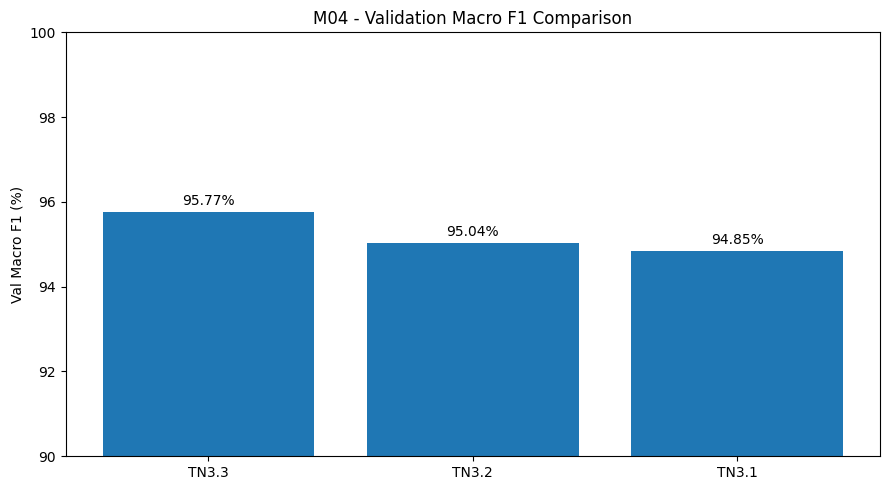

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig1_validation_macro_f1.png


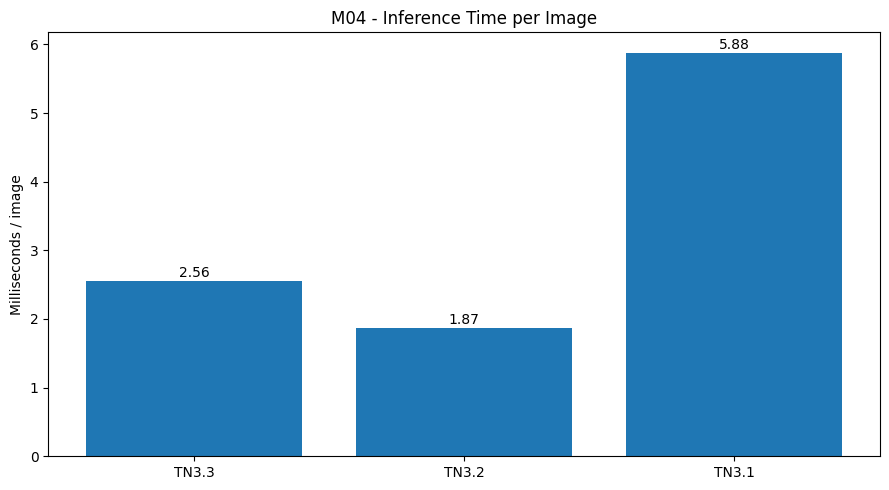

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig2_inference_time.png


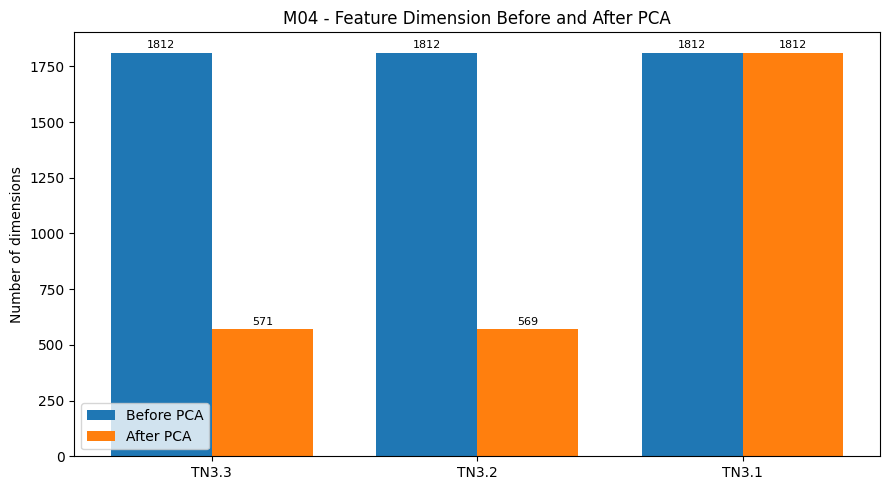

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig3_pca_dimension_reduction.png


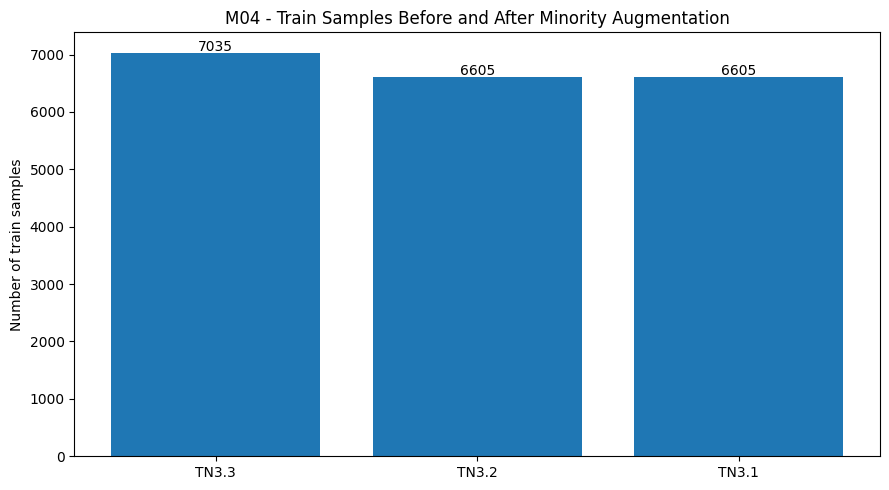

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig4_train_samples_augmentation.png
Cannot detect final metrics columns. Use fallback final metrics.


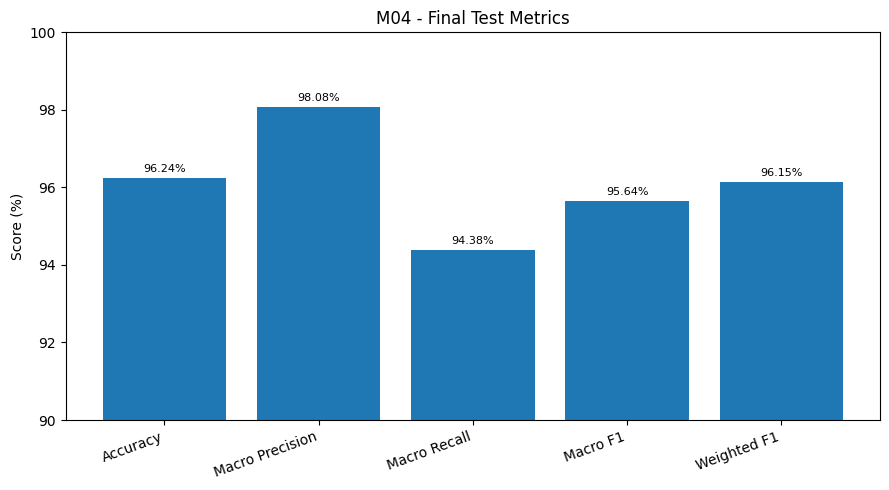

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig5_final_test_metrics.png


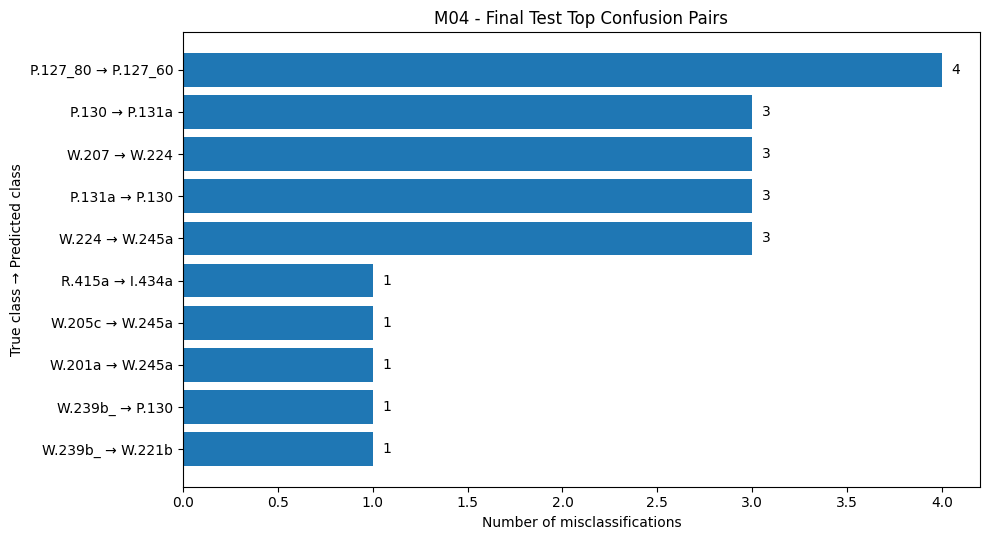

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig6_final_top_confusions.png


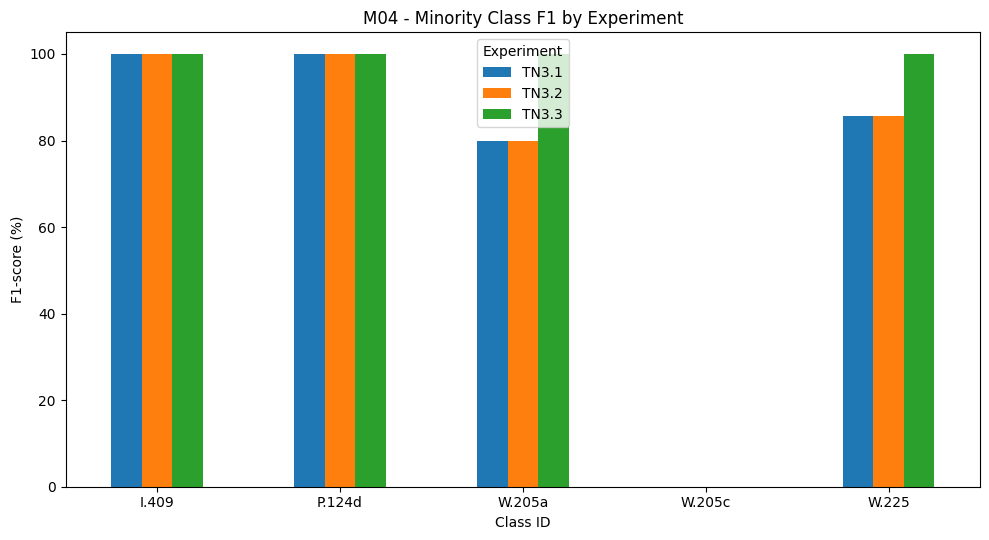

Saved: E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures\m04_fig7_minority_class_f1_by_experiment.png

Done. M04 figures are saved in:
E:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m04_outputs\figures


In [17]:
# ============================================================
# M04 VISUALIZATION CELL
# Visualize PCA, Minority Augmentation, Validation and Final Test
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Robust path setup
# ------------------------------------------------------------
CWD = Path.cwd()

def find_workspace_dir(start_path: Path):
    """
    Tự tìm thư mục workspace_Kiet từ vị trí notebook hiện tại.
    Hỗ trợ các trường hợp:
    - Đang ở AIL303m_FUDN_SUM26
    - Đang ở workspace_Kiet
    - Đang ở workspace_Kiet/m04
    """
    p = start_path.resolve()

    # Nếu đang đứng trong workspace_Kiet hoặc thư mục con của nó
    for parent in [p] + list(p.parents):
        if parent.name.lower() == "workspace_kiet":
            return parent

    # Nếu đang đứng ở project root
    candidate = p / "workspace_Kiet"
    if candidate.exists():
        return candidate

    # Nếu không tìm thấy, fallback về cwd
    return p

WORKSPACE_DIR = find_workspace_dir(CWD)
M04_OUTPUT_DIR = WORKSPACE_DIR / "m04_outputs"
FIG_DIR = M04_OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", CWD)
print("Workspace directory:", WORKSPACE_DIR)
print("M04 output directory:", M04_OUTPUT_DIR)
print("Figure output directory:", FIG_DIR)

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------
def read_csv_safe(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="utf-8")

def find_col(df, candidates):
    """
    Tìm cột linh hoạt theo nhiều tên khác nhau.
    """
    norm_map = {
        str(c).lower().strip().replace("_", " ").replace("-", " "): c
        for c in df.columns
    }

    for cand in candidates:
        cand_norm = cand.lower().strip().replace("_", " ").replace("-", " ")
        if cand_norm in norm_map:
            return norm_map[cand_norm]

    for cand in candidates:
        cand_norm = cand.lower().strip().replace("_", " ").replace("-", " ")
        for norm_name, original_name in norm_map.items():
            if cand_norm in norm_name:
                return original_name

    return None

def to_percent(series):
    """
    Convert về thang 0-100.
    Hỗ trợ:
    - 0.956
    - 95.6
    - '95.6%'
    """
    s = series.astype(str).str.replace("%", "", regex=False).str.strip()
    s = pd.to_numeric(s, errors="coerce")

    valid = s.dropna()
    if len(valid) > 0 and valid.between(0, 1).all():
        s = s * 100

    return s

def save_show(fig, filename):
    path = FIG_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

def load_if_exists(path):
    if path.exists():
        print(f"Loaded: {path}")
        return read_csv_safe(path)
    print(f"Missing, use fallback if available: {path}")
    return None

# ------------------------------------------------------------
# 3. Load M04 outputs
# ------------------------------------------------------------
validation_path = M04_OUTPUT_DIR / "validation" / "m04_validation_results_tn31_tn32_tn33.csv"
minority_report_path = M04_OUTPUT_DIR / "validation" / "m04_minority_validation_report_by_experiment.csv"

final_metrics_path = M04_OUTPUT_DIR / "final_test" / "m04_final_test_metrics.csv"
final_confusions_path = M04_OUTPUT_DIR / "final_test" / "m04_final_test_top_confusions.csv"

validation_df = load_if_exists(validation_path)
minority_df = load_if_exists(minority_report_path)
final_metrics_df = load_if_exists(final_metrics_path)
final_confusions_df = load_if_exists(final_confusions_path)

# ------------------------------------------------------------
# 4. Fallback data from your M04 notebook
#    Dùng khi CSV chưa có hoặc sai path
# ------------------------------------------------------------
fallback_validation = pd.DataFrame({
    "experiment": ["TN3.1", "TN3.2", "TN3.3"],
    "config": [
        "No PCA\nNo Aug",
        "PCA 95%\nNo Aug",
        "PCA 95%\n+ Minority Aug"
    ],
    "train_samples": [6605, 6605, 7035],
    "dim_before_pca": [1812, 1812, 1812],
    "dim_after_pca": [1812, 569, 571],
    "val_accuracy": [0.962379, 0.966019, 0.967233],
    "val_macro_recall": [0.9408, 0.9408, 0.9524],
    "val_macro_f1": [0.948522, 0.950389, 0.957736],
    "inference_ms_per_image": [5.656266, 1.788374, 1.867781],
})

fallback_final_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "value": [
        0.962397,
        0.980817,
        0.943850,
        0.956436,
        0.961452
    ]
})

fallback_final_confusions = pd.DataFrame({
    "true_class": [
        "P.127_80",
        "W.224",
        "P.131a",
        "P.130",
        "W.207",
        "W.205c",
        "W.239b_",
        "W.239b_"
    ],
    "pred_class": [
        "P.127_60",
        "W.245a",
        "P.130",
        "P.131a",
        "W.224",
        "W.245a",
        "P.130",
        "W.221b"
    ],
    "count": [4, 3, 3, 3, 3, 1, 1, 1]
})

if validation_df is None:
    validation_df = fallback_validation.copy()
    print("Using fallback validation data.")

if final_metrics_df is None:
    final_metrics_df = fallback_final_metrics.copy()
    print("Using fallback final test metrics.")

if final_confusions_df is None:
    final_confusions_df = fallback_final_confusions.copy()
    print("Using fallback final test confusions.")

# ------------------------------------------------------------
# 5. Normalize validation dataframe columns
# ------------------------------------------------------------
exp_col = find_col(validation_df, ["experiment", "exp", "ma tn", "mã tn"])
config_col = find_col(validation_df, ["config", "configuration", "cấu hình"])
train_col = find_col(validation_df, ["train samples", "train_samples", "n train"])
dim_before_col = find_col(validation_df, ["dim before pca", "dim_before_pca", "feature dimension", "dim trước pca"])
dim_after_col = find_col(validation_df, ["dim after pca", "dim_after_pca", "pca components", "dim sau pca"])
val_acc_col = find_col(validation_df, ["val accuracy", "val_accuracy", "accuracy"])
val_f1_col = find_col(validation_df, ["val macro f1", "val_macro_f1", "macro f1"])
val_recall_col = find_col(validation_df, ["val macro recall", "val_macro_recall", "macro recall"])
infer_col = find_col(validation_df, ["inference ms per image", "inference_ms_per_image", "inference", "ms/ảnh"])

# Nếu không dò được tên cột vì file dùng tên lạ, fallback về data chuẩn
required_cols = [exp_col, train_col, dim_before_col, dim_after_col, val_f1_col, infer_col]
if any(c is None for c in required_cols):
    print("Some validation columns were not found. Use fallback validation data for plotting.")
    validation_df = fallback_validation.copy()
    exp_col = "experiment"
    config_col = "config"
    train_col = "train_samples"
    dim_before_col = "dim_before_pca"
    dim_after_col = "dim_after_pca"
    val_acc_col = "val_accuracy"
    val_recall_col = "val_macro_recall"
    val_f1_col = "val_macro_f1"
    infer_col = "inference_ms_per_image"

plot_df = validation_df.copy()

# Tạo label hiển thị
if config_col is not None:
    plot_df["label"] = plot_df[exp_col].astype(str) + "\n" + plot_df[config_col].astype(str)
else:
    plot_df["label"] = plot_df[exp_col].astype(str)

plot_df["Val Macro F1 (%)"] = to_percent(plot_df[val_f1_col])
plot_df["Val Accuracy (%)"] = to_percent(plot_df[val_acc_col]) if val_acc_col else np.nan
plot_df["Val Macro Recall (%)"] = to_percent(plot_df[val_recall_col]) if val_recall_col else np.nan
plot_df["Inference ms/image"] = pd.to_numeric(plot_df[infer_col], errors="coerce")
plot_df["Train samples"] = pd.to_numeric(plot_df[train_col], errors="coerce")
plot_df["Dim before PCA"] = pd.to_numeric(plot_df[dim_before_col], errors="coerce")
plot_df["Dim after PCA"] = pd.to_numeric(plot_df[dim_after_col], errors="coerce")

# ------------------------------------------------------------
# 6. Figure 1: Validation Macro F1 comparison
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["label"], plot_df["Val Macro F1 (%)"])
ax.set_title("M04 - Validation Macro F1 Comparison")
ax.set_ylabel("Val Macro F1 (%)")
ax.set_ylim(90, 100)

for i, v in enumerate(plot_df["Val Macro F1 (%)"]):
    ax.text(i, v + 0.15, f"{v:.2f}%", ha="center")

save_show(fig, "m04_fig1_validation_macro_f1.png")

# ------------------------------------------------------------
# 7. Figure 2: Inference time comparison
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["label"], plot_df["Inference ms/image"])
ax.set_title("M04 - Inference Time per Image")
ax.set_ylabel("Milliseconds / image")

for i, v in enumerate(plot_df["Inference ms/image"]):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center")

save_show(fig, "m04_fig2_inference_time.png")

# ------------------------------------------------------------
# 8. Figure 3: Feature dimension before/after PCA
# ------------------------------------------------------------
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, plot_df["Dim before PCA"], width, label="Before PCA")
ax.bar(x + width/2, plot_df["Dim after PCA"], width, label="After PCA")
ax.set_title("M04 - Feature Dimension Before and After PCA")
ax.set_ylabel("Number of dimensions")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])
ax.legend()

for i, v in enumerate(plot_df["Dim before PCA"]):
    ax.text(i - width/2, v + 20, f"{int(v)}", ha="center", fontsize=8)

for i, v in enumerate(plot_df["Dim after PCA"]):
    ax.text(i + width/2, v + 20, f"{int(v)}", ha="center", fontsize=8)

save_show(fig, "m04_fig3_pca_dimension_reduction.png")

# ------------------------------------------------------------
# 9. Figure 4: Train samples before/after augmentation
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["label"], plot_df["Train samples"])
ax.set_title("M04 - Train Samples Before and After Minority Augmentation")
ax.set_ylabel("Number of train samples")

for i, v in enumerate(plot_df["Train samples"]):
    ax.text(i, v + 35, f"{int(v)}", ha="center")

save_show(fig, "m04_fig4_train_samples_augmentation.png")

# ------------------------------------------------------------
# 10. Figure 5: Final test metrics
# ------------------------------------------------------------
metric_col = find_col(final_metrics_df, ["metric", "Metric"])
value_col = find_col(final_metrics_df, ["value", "Value", "score", "Score"])

if metric_col is None or value_col is None:
    print("Cannot detect final metrics columns. Use fallback final metrics.")
    final_metrics_df = fallback_final_metrics.copy()
    metric_col = "metric"
    value_col = "value"

metrics_plot = final_metrics_df.copy()
metrics_plot[value_col] = to_percent(metrics_plot[value_col])

# Lọc các metric quan trọng nếu file có nhiều dòng
important_keywords = ["accuracy", "macro precision", "macro recall", "macro f1", "weighted f1"]
mask = metrics_plot[metric_col].astype(str).str.lower().apply(
    lambda x: any(k in x for k in important_keywords)
)
if mask.any():
    metrics_plot = metrics_plot[mask].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(metrics_plot[metric_col].astype(str), metrics_plot[value_col])
ax.set_title("M04 - Final Test Metrics")
ax.set_ylabel("Score (%)")
ax.set_ylim(90, 100)
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(metrics_plot[value_col]):
    ax.text(i, v + 0.15, f"{v:.2f}%", ha="center", fontsize=8)

save_show(fig, "m04_fig5_final_test_metrics.png")

# ------------------------------------------------------------
# 11. Figure 6: Final test top confusion pairs
# ------------------------------------------------------------
true_col = find_col(final_confusions_df, ["true class", "true_class", "true", "actual", "Class thật"])
pred_col = find_col(final_confusions_df, ["pred class", "pred_class", "predicted class", "prediction", "Class dự đoán"])
count_col = find_col(final_confusions_df, ["count", "num", "n", "Số lần nhầm"])

if true_col is None or pred_col is None or count_col is None:
    print("Cannot detect final confusion columns. Use fallback final confusions.")
    final_confusions_df = fallback_final_confusions.copy()
    true_col = "true_class"
    pred_col = "pred_class"
    count_col = "count"

conf_plot = final_confusions_df.copy()
conf_plot[count_col] = pd.to_numeric(conf_plot[count_col], errors="coerce")
conf_plot = conf_plot.dropna(subset=[count_col])
conf_plot["pair"] = conf_plot[true_col].astype(str) + " → " + conf_plot[pred_col].astype(str)
conf_plot = conf_plot.sort_values(count_col, ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(conf_plot["pair"], conf_plot[count_col])
ax.set_title("M04 - Final Test Top Confusion Pairs")
ax.set_xlabel("Number of misclassifications")
ax.set_ylabel("True class → Predicted class")

for i, v in enumerate(conf_plot[count_col]):
    ax.text(v + 0.05, i, str(int(v)), va="center")

save_show(fig, "m04_fig6_final_top_confusions.png")

# ------------------------------------------------------------
# 12. Optional Figure 7: Minority class Recall/F1 by experiment
# ------------------------------------------------------------
if minority_df is not None and not minority_df.empty:
    exp_c = find_col(minority_df, ["experiment", "exp"])
    class_c = find_col(minority_df, ["class", "class id", "label"])
    recall_c = find_col(minority_df, ["recall", "val recall", "recall val"])
    f1_c = find_col(minority_df, ["f1", "f1-score", "val f1", "f1 val"])

    if exp_c and class_c and recall_c and f1_c:
        mdf = minority_df.copy()
        mdf["Recall (%)"] = to_percent(mdf[recall_c])
        mdf["F1 (%)"] = to_percent(mdf[f1_c])

        # Chọn một số class nổi bật nếu có
        target_classes = ["W.205a", "W.225", "W.205c", "P.124d", "I.409"]
        mdf = mdf[mdf[class_c].astype(str).isin(target_classes)].copy()

        if not mdf.empty:
            # Vẽ F1 theo class và experiment
            pivot = mdf.pivot_table(
                index=class_c,
                columns=exp_c,
                values="F1 (%)",
                aggfunc="mean"
            )

            fig, ax = plt.subplots(figsize=(10, 5.5))
            pivot.plot(kind="bar", ax=ax)
            ax.set_title("M04 - Minority Class F1 by Experiment")
            ax.set_ylabel("F1-score (%)")
            ax.set_xlabel("Class ID")
            ax.set_ylim(0, 105)
            plt.xticks(rotation=0)
            ax.legend(title="Experiment")

            save_show(fig, "m04_fig7_minority_class_f1_by_experiment.png")
        else:
            print("Minority report loaded, but target classes were not found.")
    else:
        print("Minority report loaded, but required columns were not detected.")
else:
    print("Skip Figure 7: minority validation report not found.")

print("\nDone. M04 figures are saved in:")
print(FIG_DIR)